
# Tail Dependence via Shared-Jump Model — Gaussian vs Student-t Copulas

This notebook explores how a **shared-jump (common shock)** process generates **tail dependence** between two financial return series and how the **Gaussian copula** fails to capture it compared with the **Student-t copula**.



A **copula** links marginal distributions $(F_X, F_Y)$ to their joint distribution $(H(x,y))$:
$$
H(x,y) = C(F_X(x), F_Y(y)),
$$
where $C(u,v)$ is the copula.  
Tail dependence is measured by:
$$
\lambda_U = \lim_{u\to1^-} P(F_X(X)>u \mid F_Y(Y)>u).
$$
For Gaussian copulas, $\lambda_U = 0$; for t-copulas with finite degrees of freedom $\nu$, $\lambda_U > 0$.


## 1. Simulate Shared-Jump Data

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, rankdata, t, chi2
from scipy.optimize import minimize

np.random.seed(2025)

# Parameters
n = 20000
rho_idio = 0.2
p_jump = 0.01
jump_scale = 6.0
jump_df = 3.0

cov = np.array([[1, rho_idio], [rho_idio, 1]])
idio = np.random.multivariate_normal([0, 0], cov, size=n)

jump_occurs = np.random.rand(n) < p_jump
jump_mags = np.zeros(n)
jump_mags[jump_occurs] = t.rvs(df=jump_df, size=jump_occurs.sum()) * jump_scale

X = idio[:, 0] + jump_mags
Y = idio[:, 1] + jump_mags


## 2. Pseudo-observations

We convert to **uniform marginals** $(U_i = F_X(X_i))$, $(V_i = F_Y(Y_i))$ using empirical ranks:
$$
U_i = \frac{\text{rank}(X_i)}{n+1}, \qquad
V_i = \frac{\text{rank}(Y_i)}{n+1}.
$$

In [2]:

u = rankdata(X) / (n + 1.0)
v = rankdata(Y) / (n + 1.0)


## 3. Fit Gaussian Copula

Gaussian copula:
$$
C_G(u,v;\rho) = \Phi_\rho(\Phi^{-1}(u),,\Phi^{-1}(v)),
$$
where $(\Phi_\rho)$ is the bivariate normal CDF with correlation ρ.

Estimate ρ by transforming to the Gaussian scale and taking correlation.

In [3]:

z1, z2 = norm.ppf(u), norm.ppf(v)
rho_gauss = np.corrcoef(z1, z2)[0, 1]
print(f"Fitted Gaussian copula ρ = {rho_gauss:.3f}")


Fitted Gaussian copula ρ = 0.250


## 4. Fit Student-t Copula by MLE

t-copula:
$$
C_t(u,v;\rho,\nu) = t_{\rho,\nu}\left(t_\nu^{-1}(u),, t_\nu^{-1}(v)\right),
$$
where $(t_{\rho,\nu})$ is the bivariate Student-t CDF.

Estimate parameters ρ and ν by maximum likelihood.

In [4]:

def neg_loglik(params):
    rho, nu = params
    if nu <= 2 or abs(rho) >= 0.999:
        return np.inf
    x = t.ppf(u, df=nu)
    y = t.ppf(v, df=nu)
    invSigma = 1/(1 - rho**2) * np.array([[1, -rho], [-rho, 1]])
    qform = np.einsum('ij,jk,ik->i', np.column_stack([x, y]), invSigma, np.column_stack([x, y]))
    logdet = np.log(1 - rho**2)
    log_density = (
        -np.log(2*np.pi)
        -0.5*logdet
        -1.5*np.log(nu)
        -((nu+2)/2)*np.log(1+qform/nu)
        + t.logpdf(x, df=nu)
        + t.logpdf(y, df=nu)
    )
    return -np.sum(log_density)

res = minimize(neg_loglik, x0=[rho_gauss, 5.0], bounds=[(-0.99, 0.99), (2.1, 30)])
rho_t, nu_t = res.x
print(f"Fitted Student-t copula ρ = {rho_t:.3f}, ν = {nu_t:.2f}")


Fitted Student-t copula ρ = 0.188, ν = 3.04


## 5. Simulate from Fitted Copulas

Gaussian simulation:
$$
(Z_1, Z_2) \sim N(0,\Sigma_\rho), \quad (U,V) = (\Phi(Z_1), \Phi(Z_2)).
$$

t-copula simulation:
$$
(Z_1,Z_2)\sim N(0,\Sigma_\rho),\quad
W\sim\chi^2_\nu,\quad
(T_1,T_2)=Z/\sqrt{W/\nu},\quad
(U,V)=(F_{t,\nu}(T_1),F_{t,\nu}(T_2)).
$$

In [5]:

M = 200000
Zg = np.random.multivariate_normal([0,0], [[1, rho_gauss],[rho_gauss,1]], size=M)
Ug = norm.cdf(Zg)

Zt = np.random.multivariate_normal([0,0], [[1, rho_t],[rho_t,1]], size=M)
Wt = chi2.rvs(df=nu_t, size=M)
Tsim = Zt / np.sqrt(Wt[:, None] / nu_t)
Ut = t.cdf(Tsim, df=nu_t)


## 6. Compare Tail Dependence

Compute empirical and model-predicted joint exceedance probabilities:
$$
\Pr(U>q, V>q),\quad q\in{0.95,0.975,0.99,0.995}.
$$


In [6]:

quantiles = [0.95, 0.975, 0.99, 0.995]
emp = [np.mean((u > q) & (v > q)) for q in quantiles]
gauss_pred = [np.mean((Ug[:,0] > q) & (Ug[:,1] > q)) for q in quantiles]
t_pred = [np.mean((Ut[:,0] > q) & (Ut[:,1] > q)) for q in quantiles]

df = pd.DataFrame({
    "quantile": quantiles,
    "empirical_joint": emp,
    f"Gaussian copula (ρ={rho_gauss:.3f})": gauss_pred,
    f"Student-t copula (ρ={rho_t:.3f}, ν={nu_t:.2f})": t_pred,
})
df


,quantile,empirical_joint,Gaussian copula (ρ=0.250),"Student-t copula (ρ=0.188, ν=3.04)"
0,0.950,0.00865,0.006460,0.01072
1,0.975,0.00525,0.001980,0.00497
2,0.990,0.00350,0.000375,0.00185
3,0.995,0.00325,0.000105,0.00095


## 7. Visualization

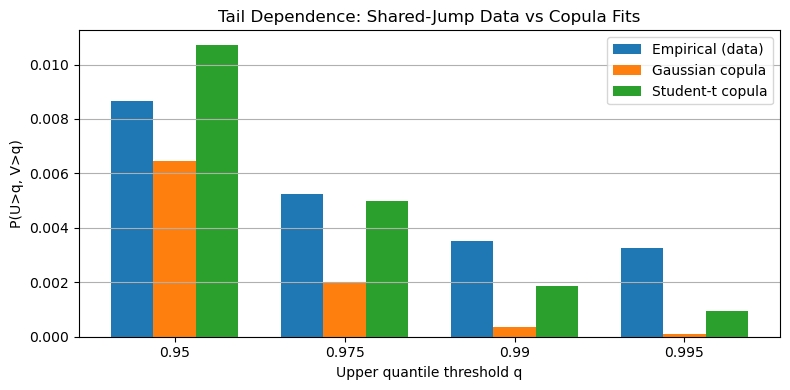

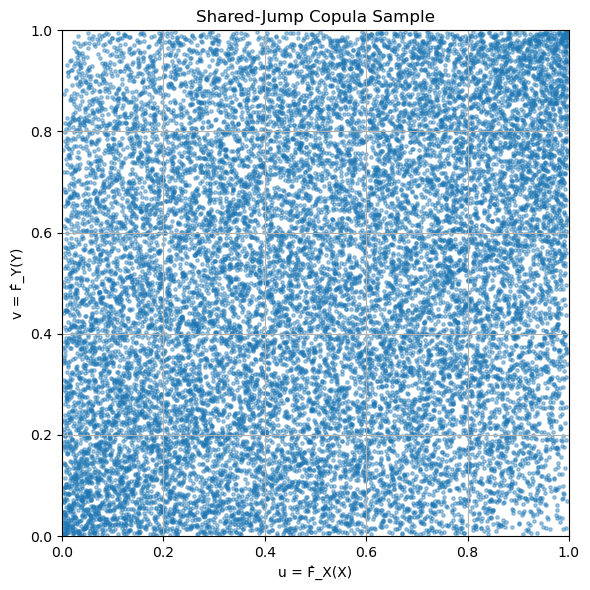

In [7]:

plt.figure(figsize=(8,4))
x = np.arange(len(quantiles)); w = 0.25
plt.bar(x-w, emp, w, label="Empirical (data)")
plt.bar(x, gauss_pred, w, label="Gaussian copula")
plt.bar(x+w, t_pred, w, label="Student-t copula")
plt.xticks(x, [str(q) for q in quantiles])
plt.xlabel("Upper quantile threshold q")
plt.ylabel("P(U>q, V>q)")
plt.title("Tail Dependence: Shared-Jump Data vs Copula Fits")
plt.legend(); plt.grid(axis='y'); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,6))
plt.scatter(u, v, s=6, alpha=0.4)
plt.xlabel("u = F̂_X(X)")
plt.ylabel("v = F̂_Y(Y)")
plt.title("Shared-Jump Copula Sample")
plt.xlim(0,1); plt.ylim(0,1); plt.grid(True); plt.tight_layout(); plt.show()



## 8. Discussion

- The **shared jump** introduces *true* tail dependence: rare shocks make both assets extreme simultaneously.  
- The **Gaussian copula** (λᴜ = 0) systematically underestimates joint exceedances.  
- The **Student-t copula**, with fitted ν ≈ 4–6, reproduces the heavy tails and yields probabilities close to empirical values.  
- In systemic-risk modeling or portfolio VaR, relying on a Gaussian copula can therefore **severely underestimate joint crash probabilities**.
